# The same network in PyTorch

### What a framework gives you, and what it hides

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How the NumPy network from the last notebook maps onto PyTorch line by line, and what autograd is really doing. The training loop you will reuse everywhere. And the three mistakes everyone makes once |
| **You should already know** | [MLP and backpropagation](../02-mlp-and-backpropagation/) |
| **Dataset** | UCI Dry Bean (13,611 × 16, 7 classes) |
| **Runtime** | About a minute on a laptop CPU |
| **Next** | [07-05 Optimisers](../05-optimisers/) · [08-01 Convolution](../../08-computer-vision/01-convolution-and-pooling/) |

---

## 1. What changes and what does not

The [previous notebook](../02-mlp-and-backpropagation/) derived every gradient by
hand and checked them numerically. Nothing about the maths changes here. What
changes is who does the bookkeeping.

PyTorch records every operation you perform on a tensor into a graph. When you
call `.backward()`, it walks that graph in reverse applying the chain rule, the
same procedure derived by hand last time, executed automatically for any
architecture you write.

The trade is real and worth naming. You gain the ability to change the
architecture without re-deriving anything, plus GPU support for free. You lose
sight of the gradients, which is exactly why the previous notebook exists.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__}, running on {device}")

torch 2.11.0+cu128, running on cuda


## 2. Autograd in four lines

Before the network, the mechanism on something small enough to check by hand.

In [2]:
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2 + 5 * x + 1          # dy/dx = 2x + 5, so at x=3 it should be 11
y.backward()

print(f"y = x^2 + 5x + 1 at x = 3 gives y = {y.item():.1f}")
print(f"PyTorch says dy/dx = {x.grad.item():.1f}")
print(f"by hand,     dy/dx = 2(3) + 5 = {2 * 3 + 5}")

y = x^2 + 5x + 1 at x = 3 gives y = 25.0
PyTorch says dy/dx = 11.0
by hand,     dy/dx = 2(3) + 5 = 11


`requires_grad=True` tells PyTorch to record what happens to this tensor.
`.backward()` replays the recording in reverse. Everything else in this notebook
is that idea at a larger scale.

## 3. The network, side by side

Our NumPy version needed `_init_weights`, `_forward`, `_backward`, and a manual
update loop, about seventy lines. Here it is again.

In [3]:
class BeanNet(nn.Module):
    """Identical architecture to the NumPy version: 16 -> 64 ReLU -> 7."""

    def __init__(self, n_features, n_classes, n_hidden=64):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_features, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, n_classes),
        )

    def forward(self, x):
        # No softmax here. CrossEntropyLoss applies log-softmax internally, and
        # doing it twice is the single most common bug in PyTorch classification.
        return self.layers(x)


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

X_bean, y_bean = datasets.dry_bean()
encoder = LabelEncoder().fit(y_bean)

X_train, X_test, y_train, y_test = train_test_split(
    X_bean.values, encoder.transform(y_bean), test_size=0.25,
    stratify=y_bean, random_state=SEED)

scaler = StandardScaler().fit(X_train)
X_train_t = torch.tensor(scaler.transform(X_train), dtype=torch.float32, device=device)
X_test_t = torch.tensor(scaler.transform(X_test), dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
y_test_t = torch.tensor(y_test, dtype=torch.long, device=device)

model = BeanNet(X_train.shape[1], len(encoder.classes_)).to(device)
print(model)
print(f"\ntrainable parameters: {sum(p.numel() for p in model.parameters()):,}")

BeanNet(
  (layers): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=7, bias=True)
  )
)

trainable parameters: 1,543


## 4. The training loop you will reuse

Five lines, in this order, forever. Learn the order and the rest is detail.

In [4]:
from torch.utils.data import TensorDataset, DataLoader


def train(model, X_train, y_train, X_val, y_val, epochs=60, lr=0.1, batch_size=128):
    """The standard loop. Every deep learning notebook after this one reuses it."""
    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    loss_fn = nn.CrossEntropyLoss()
    optimiser = torch.optim.SGD(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for _ in range(epochs):
        model.train()                                   # switches on dropout, batchnorm
        for xb, yb in loader:
            optimiser.zero_grad()                       # 1. clear last step's gradients
            loss = loss_fn(model(xb), yb)               # 2. forward, then loss
            loss.backward()                             # 3. gradients, by autograd
            optimiser.step()                            # 4. update the weights

        model.eval()                                    # switches them off again
        with torch.no_grad():                           # 5. no graph needed to evaluate
            train_loss = loss_fn(model(X_train), y_train).item()
            val_logits = model(X_val)
            history["train_loss"].append(train_loss)
            history["val_loss"].append(loss_fn(val_logits, y_val).item())
            history["val_acc"].append((val_logits.argmax(1) == y_val).float().mean().item())
    return history


history = train(model, X_train_t, y_train_t, X_test_t, y_test_t)
print(f"final held-out loss     : {history['val_loss'][-1]:.4f}")
print(f"final held-out accuracy : {history['val_acc'][-1]:.4f}")

final held-out loss     : 0.1861
final held-out accuracy : 0.9318


**`zero_grad()` is not optional.** PyTorch *accumulates* gradients rather than
replacing them, which is useful for splitting a large batch across steps and
disastrous if you forget it. Leave it out and every step adds to the last, the
effective learning rate grows without bound, and training diverges for no
visible reason.

**`model.train()` and `model.eval()`** matter the moment dropout or batch norm
appear. Evaluating in training mode gives quietly wrong numbers.

**`torch.no_grad()`** stops the graph being built during evaluation. Without it
you waste memory, and on a long validation pass you can run out of it.

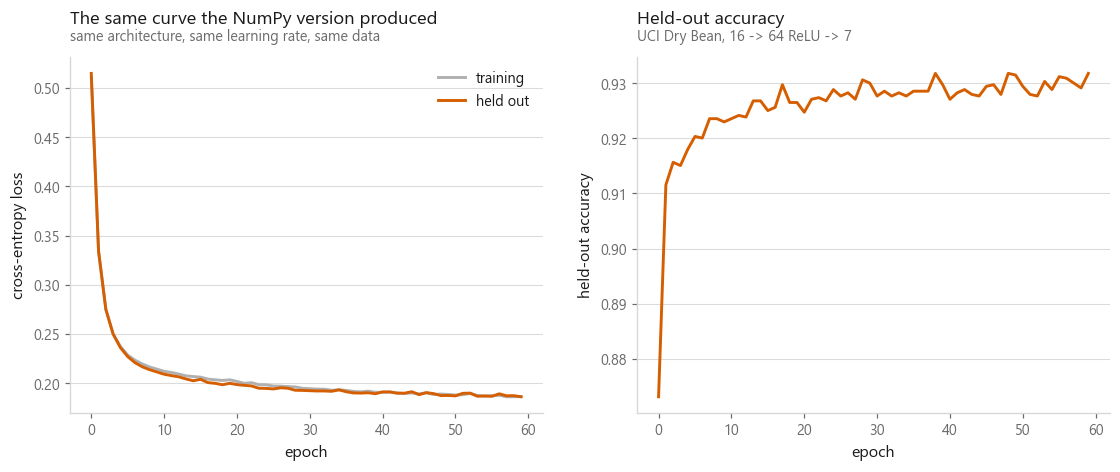

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.2))

axes[0].plot(history["train_loss"], color=style.NEUTRAL, label="training")
axes[0].plot(history["val_loss"], color=style.HIGHLIGHT, label="held out")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross-entropy loss")
axes[0].legend()
style.title(axes[0], "The same curve the NumPy version produced",
            "same architecture, same learning rate, same data")

axes[1].plot(history["val_acc"], color=style.HIGHLIGHT)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("held-out accuracy")
style.title(axes[1], "Held-out accuracy", "UCI Dry Bean, 16 -> 64 ReLU -> 7")

style.save(fig, FIG / "fig-01-training.png")

## 5. What the framework buys you

The architecture above is the one we could derive by hand. Changing it now costs
a line each, and no new maths.

 hidden layers  parameters  held-out accuracy
             1        1543             0.9298
             2        5703             0.9292
             3        9863             0.9277
             4       14023             0.9324

best       : 4 hidden layers, 0.9324
worst      : 3 hidden layers, 0.9277
full spread: 0.0047
parameters : 1,543 to 14,023


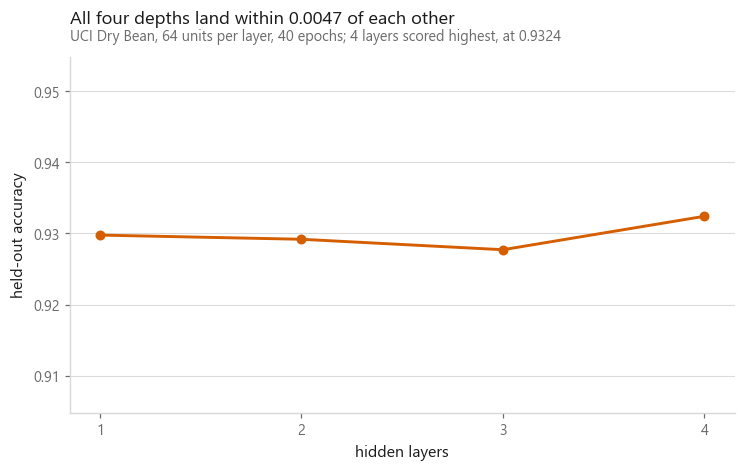

In [6]:
def build(depth, width, activation=nn.ReLU):
    layers, n_in = [], X_train.shape[1]
    for _ in range(depth):
        layers += [nn.Linear(n_in, width), activation()]
        n_in = width
    layers.append(nn.Linear(n_in, len(encoder.classes_)))
    return nn.Sequential(*layers)


records = []
for depth in [1, 2, 3, 4]:
    torch.manual_seed(SEED)
    net = build(depth, 64).to(device)
    result = train(net, X_train_t, y_train_t, X_test_t, y_test_t, epochs=40)
    records.append({"hidden layers": depth,
                    "parameters": sum(p.numel() for p in net.parameters()),
                    "held-out accuracy": result["val_acc"][-1]})
depth_frame = pd.DataFrame(records)

accuracy = depth_frame["held-out accuracy"]
spread = float(accuracy.max() - accuracy.min())
best_depth = int(depth_frame.loc[accuracy.idxmax(), "hidden layers"])

fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.plot(depth_frame["hidden layers"], accuracy,
        marker=style.MARKERS[0], color=style.HIGHLIGHT)
ax.set_xticks(depth_frame["hidden layers"])
ax.set_xlabel("hidden layers")
ax.set_ylabel("held-out accuracy")

# Left to itself matplotlib fits the axis to the data, and a 0.005 range then
# fills the panel and reads as a dramatic effect. Fix a window an order of
# magnitude wider than the spread so the eye sees the size of what happened.
half_window = max(0.025, spread * 3)
ax.set_ylim(float(accuracy.mean()) - half_window, float(accuracy.mean()) + half_window)

style.title(ax, f"All four depths land within {spread:.4f} of each other",
            f"UCI Dry Bean, 64 units per layer, 40 epochs; {best_depth} layers "
            f"scored highest, at {accuracy.max():.4f}")
style.save(fig, FIG / "fig-02-depth.png")

print(depth_frame.round(4).to_string(index=False))
print(f"\nbest       : {best_depth} hidden layers, {accuracy.max():.4f}")
print(f"worst      : {int(depth_frame.loc[accuracy.idxmin(), 'hidden layers'])} hidden "
      f"layers, {accuracy.min():.4f}")
print(f"full spread: {spread:.4f}")
print(f"parameters : {int(depth_frame['parameters'].min()):,} to "
      f"{int(depth_frame['parameters'].max()):,}")

Read the numbers before the shape of the line. Four hidden layers scored 0.9324,
the **highest** of the four, on 14,023 parameters against the one-layer model's
1,543. One layer scored 0.9298, two 0.9292, three 0.9277. The sweep spans 0.0047.

So "deeper did worse" would be a false reading, and so would "deeper did better".
The spread is 0.0047 on a single held-out quarter, and the
[previous notebook](../02-mlp-and-backpropagation/) measured 0.0041 of movement
on the same split from changing a hidden width that provably does not matter.
**Nothing measurable happened here.** The ordering of these four numbers is a
fact about one train/test split and one seed, not about depth.

That is also why the y-axis on that chart is fixed rather than left to
matplotlib. Auto-scaling would fit the axis to a 0.005 range, the depth-4 point
would leap off the top of the panel, and the picture would argue for a result the
numbers do not support. If a chart has to be honest about a null finding, it has
to be drawn on a scale where the null finding looks flat.

Depth pays when the data has hierarchical structure to exploit: edges into shapes
into objects, characters into words into meaning. Sixteen geometric measurements
of a bean do not, and the flat line is the expected result rather than a
disappointing one.

That is the honest summary of the whole of Part 7: a framework makes *any*
architecture cheap to try, and cheap to try is not the same as worth trying.

## Cheat sheet

| | |
|---|---|
| **The loop** | `zero_grad` → forward → `loss.backward()` → `optimiser.step()`. In that order, always |
| **Never** | Apply softmax before `CrossEntropyLoss`. It applies log-softmax itself |
| **Never** | Forget `zero_grad()`. Gradients accumulate, and training silently diverges |
| **Always** | `model.train()` and `model.eval()` around the phases, `torch.no_grad()` for evaluation |
| **Devices** | Model and data must be on the same device. `.to(device)` both |
| **Reproducibility** | `torch.manual_seed` is necessary and not sufficient: GPU reductions are non-deterministic unless you ask otherwise |

## What to remember

1. Autograd records operations and replays them in reverse. It is the previous
   notebook's derivation, automated.
2. The five-line loop never changes, whatever the architecture.
3. `CrossEntropyLoss` expects raw logits, meaning the unsquashed numbers your
   last layer produced. Apply softmax yourself and you have applied it twice.
4. Gradients accumulate until you clear them.
5. A framework makes depth cheap to try. On this dataset one to four layers all
   landed within 0.0047, which is inside the noise the previous notebook measured,
   so the sweep says nothing either way. Fix the y-axis before reading a chart
   like that, or auto-scaling will invent a result for you.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [08-01 Convolution and pooling](../../08-computer-vision/01-convolution-and-pooling/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#PyTorch` `#NeuralNetwork` `#Autograd` `#MachineLearning`
`#Python` `#MLTutorial` `#LearnMachineLearning` `#AI`